# marv-hyena round 6: replication and statistics

Round 6 re-runs the claims that rest on a **single measurement**, with the replicate unit, sample size
and statistic fixed in `PREDICTIONS.md` **before** this runs (P30–P35). Nothing new is attempted.

A **replicate** is a different sequence, never a rerun of the same input. That distinction is the whole
point of this round: rounds 1–3 reported single numbers, and one headline claim (the reading frame)
turned out to have no replicates at all.

| step | claim being replicated | replicate unit | n | prediction |
|---|---|---|---|---|
| R6.1 | attention does the copying; LI helps at long range | (insert, site) pair | 10 × 5 per gap | P30, P31 |
| R6.2 | six load-bearing layers | DNA set | 5 disjoint sets | P32 |
| R6.3 | MR carries the reading frame | gene | 20 genes | P33 |
| R6.4 | retrieval gain on real repeats | repeat family | ≥ 3 families | P34 |
| R6.5 | a mutation's effect leaves its position by block 7 | variant | ≥ 100 | P35 |

Every interval is a 95% percentile bootstrap over the named unit. Where several conditions are tested
at once, p-values are **Holm-corrected** and the corrected value is what the threshold applies to.

**Runtime:** A100 + High-RAM. Leave `QUICK = True` first — it runs every step at reduced n, prints a
projection, and marks the scorecard REHEARSAL. Then set `QUICK = False`.

## 0. Setup

In [1]:
# GPU check (no torch import yet: the install below may change the torch version)
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv

name, memory.total [MiB], compute_cap
NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0


In [2]:
# ---- run settings: edit these two lines only ----
QUICK = True      # True = rehearsal at reduced n. False = the real, pre-registered run (P30-P35).
USE_DRIVE = False # False = everything stays on this Colab machine. True = also cache on Google Drive.

import os
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'
    os.makedirs(os.environ['HF_HOME'], exist_ok=True)
    OUT_ROOT = '/content/drive/MyDrive/marv_hyena'
else:
    OUT_ROOT = '/content/marv_hyena_out'
OUT = f"{OUT_ROOT}/round6_{'quick' if QUICK else 'full'}"
os.makedirs(OUT, exist_ok=True)
print('HF_HOME =', os.environ.get('HF_HOME', '(default ~/.cache/huggingface)'))
print('mode    =', 'REHEARSAL (QUICK)' if QUICK else 'FULL RUN')
print('outputs =', OUT)


HF_HOME = (default ~/.cache/huggingface)
mode    = REHEARSAL (QUICK)
outputs = /content/marv_hyena_out/round6_quick


In [3]:
# Install Evo 2 + marv-hyena (~2-5 min). NO flash-attn: pip usually finds no prebuilt wheel for Colab's torch
# and compiles for hours. marv-hyena instead runs Evo 2's attention through PyTorch's built-in fused kernel
# (scaled_dot_product_attention), which is also fast on an A100 -- see marv_hyena/noflash.py.
# Colab runs Python 3.13, but every current evo2 release declares Python < 3.13, so a plain `pip install evo2`
# silently falls back to the old, incompatible 0.3.0. evo2 is pure Python, so force the current release.
# Colab also ships an empty `transformer-engine` package whose import crashes evo2; remove it (7B needs no TE).
!pip uninstall -y -q transformer-engine transformer_engine
!pip install -q --ignore-requires-python evo2==0.6.0
BRANCH = 'main'
!rm -rf marv-hyena && git clone -q -b {BRANCH} https://github.com/thebnbrkr/marv-hyena.git
!pip install -q -r marv-hyena/requirements.txt openpyxl

import sys
sys.path.insert(0, '/content/marv-hyena')

# Fail loudly now rather than 20 minutes in, after the 15 GB model download.
import subprocess, os
print('branch:', subprocess.run(['git', '-C', 'marv-hyena', 'rev-parse', '--abbrev-ref', 'HEAD'],
                                capture_output=True, text=True).stdout.strip())
for m in ('nullmodel', 'genome', 'codons', 'controls'):
    assert os.path.exists(f'marv-hyena/marv_hyena/{m}.py'), (
        f'{m}.py missing: wrong branch. round 5 needs a checkout that includes controls.py')
import re
src = open('marv-hyena/marv_hyena/controls.py').read()
for fn in ('def holm', 'def cluster_bootstrap', 'def paired_effect_size'):
    assert fn in src, f'old checkout: round 6 needs controls.{fn}'
assert 'sites: int | None' in open('marv-hyena/marv_hyena/experiments.py').read(), 'old checkout: copy_test needs sites='
print('round-6 modules present')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 123.6 MB/s eta 0:00:00
branch: main
round-6 modules present


In [4]:
# Must run before anything imports evo2/vortex: lets Vortex import without flash-attn and turns flash attention off.
from marv_hyena import noflash
noflash.prepare()

import torch, vortex, evo2
from importlib.metadata import version
print('evo2', version('evo2'), '| vtx', version('vtx'))
assert version('evo2') >= '0.6.0', 'old evo2 installed: Runtime -> Disconnect and delete runtime, then rerun from the top'
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| flash-attn package installed:', noflash.flash_attn_available())
print('GPU', torch.cuda.get_device_name(0), 'capability', torch.cuda.get_device_capability(0))
assert torch.cuda.get_device_capability(0)[0] >= 8, 'needs an Ampere+ GPU with bf16 (A100 / L4 / H100)'

evo2 0.6.0 | vtx 1.1.0
torch 2.11.0+cu128 | cuda 12.8 | flash-attn package installed: False
GPU NVIDIA A100-SXM4-80GB capability (8, 0)


In [5]:
# marv-hyena's own tests (a tiny CPU model that mirrors Vortex). Should say "95 passed".
!cd marv-hyena && python -m pytest -q

........................................................................ [ 75%]
.......................                                                  [100%]
95 passed in 7.44s


In [6]:
# Data: the annotated E. coli K-12 genome from the evo2 repo
import os, urllib.request
os.makedirs('data', exist_ok=True)
EVO2_RAW = 'https://raw.githubusercontent.com/ArcInstitute/evo2/main/notebooks'
GENOME = 'data/NC_000913.gb'
if not os.path.exists(GENOME):
    urllib.request.urlretrieve(f'{EVO2_RAW}/sparse_autoencoder/NC_000913.gb', GENOME)

import marv_hyena as mh
from marv_hyena.probes import load_sequence
genome = load_sequence(GENOME)
print(f'E. coli genome: {len(genome):,} letters')

E. coli genome: 4,641,652 letters


In [7]:
# Load Evo 2 7B (downloads ~15 GB the first time)
import time
MODEL_NAME = 'evo2_7b'
t0 = time.time()
hm = mh.HyenaModel.load(MODEL_NAME)
print(f'loaded in {time.time()-t0:.0f}s')
print(hm.describe())
RESULTS = {}

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Found complete file in repo: evo2_7b.pt


/usr/local/lib/python3.13/dist-packages/evo2/models.py:294: UserWarning: Transformer Engine not installed. Falling back to bf16 projections (use_fp8_input_projections=False). 
  warnings.warn(


  0%|          | 0/32 [00:00<?, ?it/s]

 12%|█▎        | 4/32 [00:00<00:01, 20.80it/s]

100%|██████████| 32/32 [00:00<00:00, 106.65it/s]


Extra keys in state_dict: {'blocks.26.projections._extra_state', 'unembed.weight', 'blocks.23.projections._extra_state', 'blocks.8.projections._extra_state', 'blocks.18.projections._extra_state', 'blocks.17.mixer.attn._extra_state', 'blocks.16.mixer.mixer.filter.t', 'blocks.25.projections._extra_state', 'blocks.31.mixer.dense._extra_state', 'blocks.12.projections._extra_state', 'blocks.21.projections._extra_state', 'blocks.23.mixer.mixer.filter.t', 'blocks.13.mixer.mixer.filter.t', 'blocks.4.projections._extra_state', 'blocks.9.mixer.mixer.filter.t', 'blocks.24.mixer.attn._extra_state', 'blocks.9.projections._extra_state', 'blocks.15.projections._extra_state', 'blocks.5.projections._extra_state', 'blocks.28.projections._extra_state', 'blocks.20.mixer.mixer.filter.t', 'blocks.19.projections._extra_state', 'blocks.30.projections._extra_state', 'blocks.29.projections._extra_state', 'blocks.6.mixer.mixer.filter.t', 'blocks.3.mixer.dense._extra_state', 'blocks.10.mixer.dense._extra_state', 

In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json, random, time
from marv_hyena import diagnostics, controls, probes, genome as gen, experiments, variants, codons
from marv_hyena.checks import run_smoke_checks

seq = genome[100_000:104_096]
assert run_smoke_checks(hm, seq), 'smoke checks failed: stop here'

def jsonable(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.ndarray,)): return o.tolist()
    if isinstance(o, (np.bool_,)): return bool(o)
    return str(o)

RESULTS = {'mode': 'quick' if QUICK else 'full'}
def save():
    with open(f'{OUT}/results_round6.json', 'w') as fh:
        json.dump(RESULTS, fh, default=jsonable, indent=1)

def ckpt(name, fn):
    '''Run fn once and checkpoint it, so a disconnect loses at most one step.'''
    path = f'{OUT}/r6_{name}.json'
    if os.path.exists(path):
        print(f'{name}: loaded checkpoint'); return json.load(open(path))
    t0 = time.time(); out = fn(); dt = time.time() - t0
    json.dump(out, open(path, 'w'), default=jsonable)
    print(f'{name}: {dt:.0f}s'); return out

# Five DNA sets from disjoint regions, each mixing coding and intergenic sequence (P32's replicate unit).
rng = random.Random(0)
DNA_SETS = [genome[o:o + 4096] for o in sorted(rng.sample(range(10_000, len(genome) - 5000), 5))]
print('5 DNA sets, GC fractions:', [round(gen.gc_content(s), 3) for s in DNA_SETS])
HEALTH_SEQ = DNA_SETS[0]
BASE_HEALTH = [diagnostics.health(hm, s)['health_acc'] for s in DNA_SETS]
print('baseline health per set:', [round(h, 3) for h in BASE_HEALTH])
RESULTS['baseline_health'] = BASE_HEALTH
save()

[PASS] embed + sum(writes) == final residual  rel_err=8.21e-06
[PASS] trace rows sum to real logit diff  sum=+8.541 actual=+8.505
[PASS] distance bands reconstruct block 14 (se)  rel_err=3.98e-03
[PASS] distance bands reconstruct block 15 (mr)  rel_err=3.41e-03
[PASS] distance bands reconstruct block 16 (li)  rel_err=2.66e-03
[PASS] block 0 receptive field small enough to enumerate  measured 9 letters
[PASS] hooks removed after intervention  
[PASS] mean-ablating LI mixers changes the output  

8/8 checks passed
5 DNA sets, GC fractions: [0.566, 0.515, 0.526, 0.539, 0.544]
baseline health per set: [0.858, 0.727, 0.849, 0.797, 0.633]


## R6.1 Copying, with inserts and sites as separate replicates (P30, P31)

Rounds 1–3 varied one seed, which moved the insert *and* the insertion site together, so 3 numbers came
from 3 confounded replicates. `copy_test(seeds=10, sites=5)` crosses 10 random inserts with 5
independent genomic offsets: **50 replicates per gap**, and a bootstrap can resample inserts or sites
separately. The reported interval is the wider of the two.

In [9]:
N_INS, N_SITE = (3, 2) if QUICK else (10, 5)
conds = experiments.make_conditions(hm, exclude_blocks=[0, 1, 4, 9, 29, 30])
copy_rows = ckpt('copy', lambda: experiments.copy_test(
    hm, genome, gaps=(100, 1000, 10000), insert_len=200, seeds=N_INS, sites=N_SITE,
    conditions=conds, health_seq=HEALTH_SEQ, verbose=False))
RESULTS['copy'] = copy_rows; save()

cp = pd.DataFrame(copy_rows)
print(f'{len(cp)} rows = {N_INS} inserts x {N_SITE} sites x 3 gaps x {cp.condition.nunique()} conditions')

def boot_mean(vals, groups, n_boot=4000, seed=0):
    '''Percentile interval resampling GROUPS, not rows.'''
    g = {}
    for v, k in zip(vals, groups): g.setdefault(k, []).append(v)
    keys, r = list(g), np.random.default_rng(seed)
    draws = [np.mean([x for i in r.integers(0, len(keys), len(keys)) for x in g[keys[i]]])
             for _ in range(n_boot)]
    return float(np.mean(vals)), tuple(np.percentile(draws, [2.5, 97.5]))

rows = []
for (cond, gap), sub in cp.groupby(['condition', 'gap']):
    m, ci_i = boot_mean(sub.second_acc.values, sub.insert_seed.values)
    _, ci_s = boot_mean(sub.second_acc.values, sub.site_seed.values)
    # report the wider of the two replicate units
    wide = ci_i if (ci_i[1] - ci_i[0]) >= (ci_s[1] - ci_s[0]) else ci_s
    rows.append({'condition': cond, 'gap': gap, 'n': len(sub), 'mean_second_acc': m,
                 'ci_by_insert': ci_i, 'ci_by_site': ci_s, 'ci_reported': wide,
                 'unit': 'insert' if wide is ci_i else 'site',
                 'health': float(sub.health_acc.iloc[0])})
COPY = pd.DataFrame(rows)
RESULTS['copy_summary'] = rows; save()
print(COPY.to_string(index=False))

copy: 101s
90 rows = 3 inserts x 2 sites x 3 gaps x 5 conditions
                condition   gap  n  mean_second_acc                               ci_by_insert                                 ci_by_site                                ci_reported   unit   health
                    -attn   100  6         0.263889  (0.21111111342906952, 0.3222222328186035)   (0.2500000049670537, 0.2777777860562007)  (0.21111111342906952, 0.3222222328186035) insert 0.702564
                    -attn  1000  6         0.259259 (0.21388889104127884, 0.29722222685813904)   (0.2444444497426351, 0.2740740825732549) (0.21388889104127884, 0.29722222685813904) insert 0.702564
                    -attn 10000  6         0.258333 (0.23055555671453476, 0.29722222685813904) (0.25740741193294525, 0.25925926367441815) (0.23055555671453476, 0.29722222685813904) insert 0.702564
-li (keep L0,1,4,9,29,30)   100  6         0.949074   (0.9305555522441864, 0.9638888835906982)   (0.9018518527348837, 0.9962962865829468)   (0.9018

P30: attention ablated, mean second-copy accuracy < 0.35 and interval excludes 0.90
  gap    100: 0.264  CI 0.211-0.322  < 0.35: True   excludes 0.90: True
  gap   1000: 0.259  CI 0.214-0.297  < 0.35: True   excludes 0.90: True
  gap  10000: 0.258  CI 0.231-0.297  < 0.35: True   excludes 0.90: True
  unablated >= 0.95 at every gap: True

P31: without LI, 10k-gap mean < 0.80 and interval excludes the unablated mean;
     at a 100-letter gap the interval includes it
  gap    100: -li 0.949 CI 0.902-0.996 | unablated 1.000 | includes it: False
  gap  10000: -li 0.660 CI 0.467-0.854 | unablated 1.000 | includes it: False


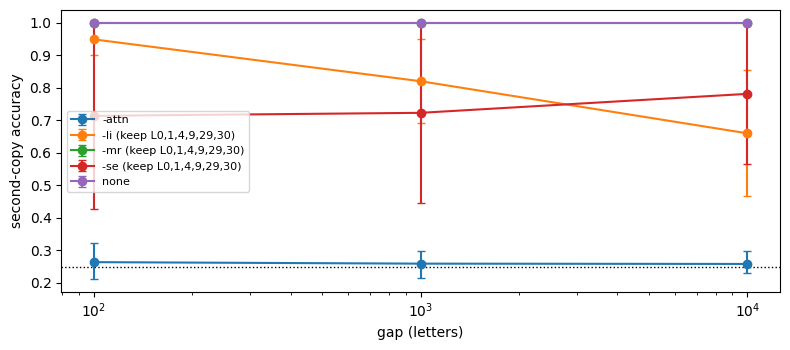

In [10]:
# P30 and P31's decision numbers.
def get(cond, gap):
    m = COPY[COPY.condition.str.startswith(cond) & (COPY.gap == gap)]
    assert len(m), f'no condition starting {cond!r}: make_conditions produced {sorted(COPY.condition.unique())}'
    return m.iloc[0]
none = {g: get('none', g) for g in (100, 1000, 10000)}
attn = {g: get('-attn', g) for g in (100, 1000, 10000)}
li = {g: get('-li', g) for g in (100, 1000, 10000)}

print('P30: attention ablated, mean second-copy accuracy < 0.35 and interval excludes 0.90')
for g in (100, 1000, 10000):
    a = attn[g]
    print(f"  gap {g:6d}: {a.mean_second_acc:.3f}  CI {a.ci_reported[0]:.3f}-{a.ci_reported[1]:.3f}  "
          f"< 0.35: {a.mean_second_acc < 0.35}   excludes 0.90: {a.ci_reported[1] < 0.90}")
print('  unablated >= 0.95 at every gap:', all(none[g].mean_second_acc >= 0.95 for g in none))
print()
print('P31: without LI, 10k-gap mean < 0.80 and interval excludes the unablated mean;')
print('     at a 100-letter gap the interval includes it')
for g in (100, 10000):
    l, n_ = li[g], none[g]
    inc = l.ci_reported[0] <= n_.mean_second_acc <= l.ci_reported[1]
    print(f"  gap {g:6d}: -li {l.mean_second_acc:.3f} CI {l.ci_reported[0]:.3f}-{l.ci_reported[1]:.3f} "
          f"| unablated {n_.mean_second_acc:.3f} | includes it: {inc}")

fig, ax = plt.subplots(figsize=(8, 3.6))
for cond in COPY.condition.unique():
    sub = COPY[COPY.condition == cond].sort_values('gap')
    lo = [r.ci_reported[0] for r in sub.itertuples()]; hi = [r.ci_reported[1] for r in sub.itertuples()]
    ax.errorbar(sub.gap, sub.mean_second_acc,
                yerr=[sub.mean_second_acc - lo, np.array(hi) - sub.mean_second_acc],
                marker='o', capsize=3, label=cond)
ax.set_xscale('log'); ax.set_xlabel('gap (letters)'); ax.set_ylabel('second-copy accuracy')
ax.axhline(0.25, color='k', ls=':', lw=1); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## R6.2 The load-bearing map, on 5 independent DNA sets (P32)

Rounds 2–5 measured health on **one** sequence. The rule fixed in advance: a layer is load-bearing only
if removing its mixer leaves health **below 0.5 on all 5 sets**.

In [11]:
lb_rows = ckpt('load_bearing', lambda: [
    dict(set_index=i, **r) for i, s in enumerate(DNA_SETS)
    for r in diagnostics.find_load_bearing(hm, s)])
RESULTS['load_bearing'] = lb_rows; save()

lb = pd.DataFrame(lb_rows)
piv = lb.pivot_table(index=['block', 'kind'], columns='set_index', values='health_acc')
CUT, N_SETS = 0.5, len(DNA_SETS)
piv['below_cut_in'] = (piv[list(range(N_SETS))] < CUT).sum(axis=1)
LB6 = sorted(b for (b, k), r in piv.iterrows() if r.below_cut_in == N_SETS)
print(piv[piv.below_cut_in > 0].round(3).to_string())
print()
print(f'load-bearing by the pre-registered rule (health < {CUT} on all {N_SETS} sets): {LB6}')
# Descriptive companion, not part of P32: the same rule relative to each set's own baseline.
rel = {}
for (b, k), r in piv.iterrows():
    rel[b] = sum(r[i] < 0.6 * BASE_HEALTH[i] for i in range(N_SETS))
LB_REL = sorted(b for b, n in rel.items() if n == N_SETS)
print(f'(descriptive) same rule at 60% of each set\'s own baseline: {LB_REL}')
if len(LB6) == hm.n_blocks:
    print('NOTE: every block is below the absolute cutoff. Expected on an untrained test model whose '
          'baseline health is already under 0.5; on evo2_7b the baseline is ~0.70.')
EXPECTED = [0, 1, 4, 9, 29, 30]
print(f'P32 predicted exactly {EXPECTED}  ->  match: {LB6 == EXPECTED}')
partial = sorted(b for (b, k), r in piv.iterrows() if 0 < r.below_cut_in < N_SETS)
print(f'borderline (breaks on some sets but not all): {partial}')
RESULTS['load_bearing_rule'] = {'cutoff': CUT, 'n_sets': N_SETS, 'load_bearing': LB6,
                                'load_bearing_relative': LB_REL, 'borderline': partial,
                                'expected': EXPECTED}; save()

load_bearing: 123s
set_index       0      1      2      3      4  below_cut_in
block kind                                                 
0     se    0.291  0.264  0.286  0.284  0.284             5
1     mr    0.434  0.354  0.370  0.386  0.383             5
4     se    0.397  0.325  0.359  0.390  0.322             5
9     li    0.244  0.252  0.236  0.241  0.235             5
29    mr    0.282  0.350  0.260  0.268  0.271             5
30    li    0.282  0.246  0.260  0.268  0.271             5

load-bearing by the pre-registered rule (health < 0.5 on all 5 sets): [0, 1, 4, 9, 29, 30]
(descriptive) same rule at 60% of each set's own baseline: [0, 4, 9, 29, 30]
P32 predicted exactly [0, 1, 4, 9, 29, 30]  ->  match: True
borderline (breaks on some sets but not all): []


## R6.3 The reading frame, on 20 genes (P33)

The MR claim currently rests on **one** region — the weakest-supported headline result in the project.
Genes are drawn at random; minus-strand genes are reverse-complemented and overlapping genes excluded,
so a codon position means the same thing in every one.

In [12]:
N_GENES = 4 if QUICK else 20
whole = probes.genbank_track(GENOME, 0, len(genome))

def pick_genes(n, seed=0, min_len=900):
    '''Forward-strand CDS features, long enough to measure periodicity, non-overlapping.'''
    from Bio import SeqIO
    rec = next(SeqIO.parse(GENOME, 'genbank'))
    feats = [(int(f.location.start), int(f.location.end), int(f.location.strand or 1))
             for f in rec.features if f.type == 'CDS']
    feats.sort()
    keep = []
    for i, (s, e, st) in enumerate(feats):
        if e - s < min_len: continue
        if i and feats[i-1][1] > s: continue              # overlaps the previous gene
        if i + 1 < len(feats) and e > feats[i+1][0]: continue
        if st != 1: continue                              # forward strand only: codon phase is defined
        keep.append((s, e, st))
    return random.Random(seed).sample(keep, min(n, len(keep)))

GENES = pick_genes(N_GENES)
print(f'{len(GENES)} genes | strands: {pd.Series([g[2] for g in GENES]).value_counts().to_dict()}')

def gene_rows():
    out = []
    for gi, (s, e, st) in enumerate(GENES):
        tr = probes.genbank_track(GENOME, max(0, s - 500), min(len(genome), e + 100))
        for r in experiments.codon_test(hm, tr, conditions=conds):
            out.append(dict(gene=gi, start=s, strand=st, **r))
    return out
frame_rows = ckpt('reading_frame', gene_rows)
RESULTS['reading_frame'] = frame_rows; save()

fr = pd.DataFrame(frame_rows)
per = []
for (cond, gi), sub in fr.groupby(['condition', 'gene']):
    d = {r.region: r.acc for r in sub.itertuples()}
    if {'codon_pos1', 'codon_pos2', 'codon_pos3'} <= set(d):
        v = max(d['codon_pos1'], d['codon_pos2']) - d['codon_pos3']
        if v == v:                                        # drop NaN genes (too short to score)
            per.append({'condition': cond, 'gene': gi, 'periodicity': v,
                        'health': float(sub.health_acc.iloc[0])})
PER = pd.DataFrame(per)
assert len(PER), 'no gene produced a periodicity value: raise min_len or check the track'
print(f'{PER.gene.nunique()} genes scored of {len(GENES)} picked')
rows = []
for cond, sub in PER.groupby('condition'):
    m, ci = boot_mean(sub.periodicity.values, sub.gene.values)
    rows.append({'condition': cond, 'n_genes': len(sub), 'mean_periodicity': m, 'ci95': ci,
                 'health': float(sub.health.iloc[0])})
FRAME = pd.DataFrame(rows).sort_values('mean_periodicity')
RESULTS['reading_frame_summary'] = rows; save()
print(FRAME.to_string(index=False))

n_ci = FRAME[FRAME.condition == 'none'].iloc[0]
print('\nP33: removing MR lowers periodicity and its interval excludes the unablated interval;')
print('     removing SE does not')
for pre in ('-mr', '-se'):
    m = FRAME[FRAME.condition.str.startswith(pre)]
    if not len(m):
        print(f'  {pre:28s} condition absent from make_conditions on this model'); continue
    r = m.iloc[0]
    sep = r.ci95[1] < n_ci.ci95[0]
    print(f"  {r.condition:28s} {r.mean_periodicity:+.4f} CI {r.ci95[0]:+.4f}..{r.ci95[1]:+.4f}  "
          f"excludes unablated CI ({n_ci.ci95[0]:+.4f}..): {sep}")

4 genes | strands: {1: 4}
reading_frame: 23s
4 genes scored of 4 picked
                condition  n_genes  mean_periodicity                                         ci95   health
-mr (keep L0,1,4,9,29,30)        4          0.035090 (-0.005718337928782513, 0.07589800403516359) 0.459489
-se (keep L0,1,4,9,29,30)        4          0.107574   (0.05966617121085217, 0.15067237714368065) 0.484462
-li (keep L0,1,4,9,29,30)        4          0.147690   (0.10233866944511036, 0.21079022790697427) 0.517758
                    -attn        4          0.172560   (0.07432838593150826, 0.26732895923781835) 0.496670
                     none        4          0.276048   (0.23000839719572008, 0.32342077499168276) 0.649834

P33: removing MR lowers periodicity and its interval excludes the unablated interval;
     removing SE does not
  -mr (keep L0,1,4,9,29,30)    +0.0351 CI -0.0057..+0.0759  excludes unablated CI (+0.2300..): True
  -se (keep L0,1,4,9,29,30)    +0.1076 CI +0.0597..+0.1507  excludes unab

## R6.4 Retrieval gain on real repeat families (P34)

Round 4 used one family, 16S rRNA, which the model already predicts at 98.9% on first sight — so there
was no headroom for retrieval to add anything. The rule fixed in advance: **drop any family whose first
copy scores above 95%** before looking at its gain.

In [13]:
N_FAM = 2 if QUICK else 6
fams = gen.find_repeat_families(GENOME, types=('rRNA', 'mobile_element', 'CDS'),
                                min_copies=2, min_len=250)
print(f'{len(fams)} families found:')
for f in fams[:8]: print('  ', f)
fams = fams[:N_FAM]
background = genome[1_500_000:1_560_000]

def fam_rows():
    out = []
    for f in fams:
        pr = gen.repeat_probes(background, f, gaps=(1000, 10000), insert_len=200, lead=1000, seed=0)
        for r in gen.run_repeat_test(hm, pr, conditions=conds):
            out.append({**r, 'family': f.name})   # run_repeat_test already sets 'family'
    return out
rep_rows = ckpt('repeats', fam_rows)
RESULTS['repeats'] = rep_rows; save()

rp = pd.DataFrame(rep_rows)
real = rp[(rp.arm == 'real') & (rp.condition == 'none')]
HEADROOM = 0.95
first = real.groupby('family').first_acc.mean()
passed = sorted(first[first <= HEADROOM].index)
print(f'\nheadroom rule (first-copy accuracy <= {HEADROOM}), fixed before the run:')
for fam, acc in first.items():
    print(f"  {fam[:46]:48s} first-copy {acc:.3f}  ->  {'KEEP' if fam in passed else 'EXCLUDED'}")
RESULTS['headroom'] = {'cutoff': HEADROOM, 'first_acc': first.to_dict(), 'passed': passed}; save()

if len(passed) < 3:
    print(f'\nP34 UNTESTABLE: only {len(passed)} families pass the headroom rule (needed 3).')
else:
    keep = rp[rp.family.isin(passed) & (rp.arm == 'real')]
    rows = []
    for cond, sub in keep.groupby('condition'):
        gain = sub.second_lp - sub.first_lp
        m, ci = boot_mean(gain.values, sub.family.values)
        rows.append({'condition': cond, 'n_families': sub.family.nunique(),
                     'mean_gain_nats': m, 'ci95': ci})
    REP = pd.DataFrame(rows)
    RESULTS['repeat_summary'] = rows; save()
    print(); print(REP.to_string(index=False))
    g0 = REP[REP.condition == 'none'].iloc[0].mean_gain_nats
    ga = REP[REP.condition == '-attn'].iloc[0].mean_gain_nats
    print(f'\nP34: unablated gain > 0.5 nats: {g0 > 0.5} ({g0:.3f});  '
          f'-attn cuts it by >= 70%: {(1 - ga / g0) >= 0.70 if g0 else float("nan")} '
          f'(kept {ga / g0:.1%})' if g0 else '')

15 families found:
   RepeatFamily('IS5 family transposase and trans-activator', CDS, 12 copies, 981 bp, k-mer similarity 0.903)
   RepeatFamily('23S ribosomal RNA', rRNA, 7 copies, 2904 bp, k-mer similarity 0.963)
   RepeatFamily('16S ribosomal RNA', rRNA, 7 copies, 1542 bp, k-mer similarity 0.949)
   RepeatFamily('IS2', mobile_element, 7 copies, 706 bp, k-mer similarity 1.000)
   RepeatFamily('IS3', mobile_element, 5 copies, 1255 bp, k-mer similarity 1.000)
   RepeatFamily('IS2 insertion element protein InsB', CDS, 5 copies, 906 bp, k-mer similarity 1.000)
   RepeatFamily('IS3 element protein InsF', CDS, 5 copies, 867 bp, k-mer similarity 1.000)
   RepeatFamily('IS2 insertion element repressor InsA', CDS, 5 copies, 366 bp, k-mer similarity 1.000)
repeats: 88s

headroom rule (first-copy accuracy <= 0.95), fixed before the run:
  23S ribosomal RNA                                first-copy 0.956  ->  EXCLUDED
  IS5 family transposase and trans-activator       first-copy 0.656  ->  KEEP


## R6.5 Where a mutation's effect goes, at n ≥ 100 (P35)

Five variants is not a distribution. The **hand-off block** is defined in advance as the first block
after which under 10% of the downstream effect still transfers when the mutated position's residual is
patched.

12 variants: {'silent': 3, 'missense': 3, 'nonsense': 3, 'noncoding': 3}
propagation: 162s

10 of 12 variants reached the 10% threshold
  median hand-off block 24 | IQR 4-28 | 90th pct 28
           count   50%   min   max
var_class                         
missense     3.0  27.0  23.0  28.0
noncoding    2.0   3.0   2.0   4.0
nonsense     2.0  14.5   4.0  25.0
silent       3.0  28.0   6.0  29.0

P35: median <= 7: False | 90th pct <= 12: False


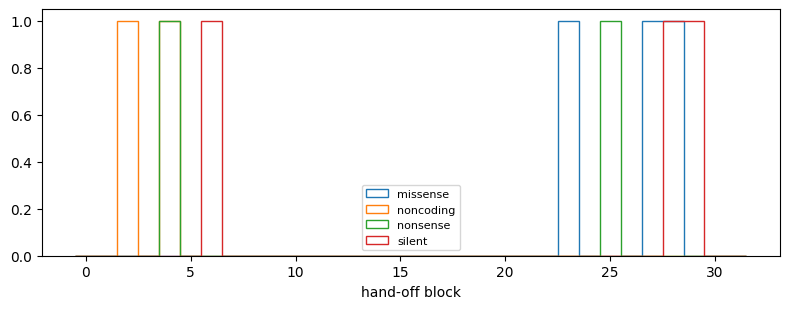

In [14]:
N_VAR = 12 if QUICK else 120
TH = 0.10   # hand-off = first block where the transferred fraction drops below this

def sample_variants(n, seed=0):
    '''In-silico E. coli variants spanning silent, missense, nonsense and non-coding.'''
    r = random.Random(seed)
    tr = probes.genbank_track(GENOME, 0, len(genome))
    out, per = [], max(1, n // 4)
    d = codons.design_sites(tr, max_sites=None, min_spacing=500, seed=seed)
    for kind, design, arm in (('silent', 'fourfold', 'a'), ('missense', 'matched', 'b'),
                              ('nonsense', 'stop_matched', 'a'), ('noncoding', 'noncoding', 'a')):
        sites = d.get(design, [])
        for s in r.sample(sites, min(per, len(sites))):
            a = getattr(s, arm)
            out.append((kind, s.pos, s.ref, a.alt))
    return out

VARS = sample_variants(N_VAR)
print(f'{len(VARS)} variants:', pd.Series([v[0] for v in VARS]).value_counts().to_dict())

def depth_rows():
    out = []
    for kind, pos, ref, alt in VARS:
        v = variants.make_variant(genome, pos, ref, alt, window=4096)
        for r in variants.residual_patch_by_depth(hm, v, span=200):
            out.append({**r, 'var_class': kind, 'pos': pos})   # r's own 'kind' is the OPERATOR kind
    return out
depth = ckpt('propagation', depth_rows)
RESULTS['propagation'] = depth; save()

dp = pd.DataFrame(depth)
# residual_patch_by_depth returns depth / kind (the OPERATOR kind) / metric / fraction
hand = []
for pos, sub in dp.groupby('pos'):
    sub = sub[sub.depth >= 0].sort_values('depth')
    below = sub[sub.fraction.abs() < TH]
    if len(below):
        hand.append({'pos': pos, 'var_class': sub.var_class.iloc[0],
                     'handoff_block': int(below.depth.iloc[0])})
HO = pd.DataFrame(hand)
RESULTS['handoff'] = {'threshold': TH, 'rows': hand}; save()
print(f'\n{len(HO)} of {dp.pos.nunique()} variants reached the {TH:.0%} threshold')
if len(HO):
    q = HO.handoff_block.quantile([0.25, 0.5, 0.9]).to_dict()
    print(f"  median hand-off block {q[0.5]:.0f} | IQR {q[0.25]:.0f}-{HO.handoff_block.quantile(.75):.0f} "
          f"| 90th pct {q[0.9]:.0f}")
    print(HO.groupby('var_class').handoff_block.describe()[['count', '50%', 'min', 'max']].to_string())
    print(f"\nP35: median <= 7: {q[0.5] <= 7} | 90th pct <= 12: {q[0.9] <= 12}")
    fig, ax = plt.subplots(figsize=(8, 3.2))
    for k, sub in HO.groupby('var_class'):
        ax.hist(sub.handoff_block, bins=np.arange(-0.5, hm.n_blocks + 0.5), histtype='step', lw=2, label=k)
    ax.set_xlabel('hand-off block'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Save

Executed notebook to `results/round6/marv_hyena_round6_colab_result.ipynb`, with `results_round6.json`
beside it. Record the outcomes in `PREDICTIONS.md` **as they came out**.

In [15]:
import shutil
save(); shutil.copy(f'{OUT}/results_round6.json', 'results_round6.json')
print('wrote results_round6.json', os.path.getsize('results_round6.json'), 'bytes')
print('keys:', list(RESULTS))
if QUICK:
    print('=' * 78)
    print('REHEARSAL (QUICK = True): reduced n everywhere. Do NOT record these outcomes.')
    print('Set QUICK = False and Run all again.')
    print('=' * 78)
try:
    from google.colab import files
    files.download('results_round6.json')
except Exception as e:
    print('(download skipped:', e, ')')

wrote results_round6.json 176243 bytes
keys: ['mode', 'baseline_health', 'copy', 'copy_summary', 'load_bearing', 'load_bearing_rule', 'reading_frame', 'reading_frame_summary', 'repeats', 'headroom', 'propagation', 'handoff']
REHEARSAL (QUICK = True): reduced n everywhere. Do NOT record these outcomes.
Set QUICK = False and Run all again.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>